# Market efficiency decision rule

## Executive summary

This notebook asks whether systematic pricing patterns in football betting markets can be identified, and whether price dispersion can turn those patterns into economically meaningful out-of-sample opportunities.

The central empirical result is constructive: using all available seasons, an 11-league top-division universe, and an expanding-window out-of-sample design, the decision rule produces positive flat-stake ROI for the `market_maximum` opportunity set. The `average_market` result is economically inactive because it selects only one bet.

This is not framed as a search for naive bookmaker mistakes. Systematic pricing patterns may reflect structural effects such as bettor demand, favourite-longshot bias, or bookmaker margin allocation. The empirical question is whether these patterns are persistent enough to define betting ranges with positive out-of-sample value.

This points to a price-selection / price-dispersion effect. The average quoted market price is highly informative and difficult to exploit directly, but better available quoted prices can create measurable value when selected through a disciplined market-efficiency rule.

Intuitively, the rule searches for implied-probability ranges where historical forecast errors are consistently positive. A range is accepted only when the lower 95% confidence bound of the fitted error curve remains above zero, and bets are then placed out of sample when current odds fall inside that accepted range.

Methodology in brief - full details are given in Section 3:

- use raw implied probability, \(p = 1 / odds\);
- estimate systematic pricing-error curves using past seasons only;
- apply expanding-window walk-forward calibration, so each test season excludes the current and future seasons;
- bet only where the lower 95% confidence bound of the fitted error curve is positive;
- compare `average_market` with `market_maximum`;
- evaluate flat-stake ROI, fractional-Kelly staking, and bootstrap robustness.

`market_maximum` is the best quoted price recorded within the Football-Data coverage universe and is directly relevant for studying price dispersion. Football-Data states that odds snapshots are collected before fixtures are played: Friday afternoons for weekend games and Tuesday afternoons for midweek games. The data contains odds snapshots but does not provide venue-level timestamps, so the exact timing and availability of each quoted price cannot be independently verified.


## 1. Setup and configuration

Configuration is kept visible so the market outcome, leagues, and seasons can be changed without editing the rest of the notebook.

The economic presentation focuses on:

- `average_market`: the average quoted market price;
- `market_maximum`: the best quoted market price available in the Football-Data file.

`market_maximum` is a recorded best-price opportunity-set proxy. Exact venue-level timing, liquidity, and availability cannot be independently verified from the dataset.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from football_edge.market_efficiency import (
    MARKET_ODDS_SOURCES,
    MARKET_OUTCOME_CONFIG,
    MARKET_PRIMARY_SOURCES,
    MARKET_SOURCE_COLORS,
    PAPER_TOP_DIVISIONS,
    SUPPORTED_ESTIMATION_METHODS,
    build_robustness_diagnostics,
    build_source_panel,
    load_market_efficiency_matches,
    run_kelly_analysis,
    run_paper_rule_analysis,
)
from football_edge.plotting import (
    plot_kelly_diagnostics,
    plot_market_efficiency_margins,
    plot_market_maximum_robustness,
    plot_paper_rule_by_league,
    plot_paper_rule_by_season,
    plot_paper_rule_total_results,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
# Main configuration.
MARKET_OUTCOME = "home_win"  # over_2_5, under_2_5, home_win, draw, away_win

# Fast data-loading path. Uses the faithful per-season Parquet files created by
# notebooks/04_build_all_euro_season_parquets.ipynb. If a selected Parquet file
# is missing, the notebook falls back to the original Excel loader.
USE_SEASON_PARQUET = True
SEASON_PARQUET_DIR = PROJECT_ROOT / "data" / "processed" / "all_euro_by_season"

# Published specification: 11 first-tier European leagues, matching the
# paper-style all-Europe setup. Use None for all discovered divisions.
LEAGUES_TO_INCLUDE = None
DIVISIONS_TO_INCLUDE = PAPER_TOP_DIVISIONS

SEASONS_TO_INCLUDE = None  # Use None for all discovered seasons.

MIN_TRAIN_SEASONS = 2
MIN_TRAIN_MATCHES = 100

# None = expanding window using all previous seasons.
# Integer N = rolling window using the last N previous seasons available for each source-league.
# If fewer than N previous seasons are available, all available previous seasons are used.
TRAINING_WINDOW_SEASONS = None
CONFIDENCE_Z = 1.96

# Regression estimator used for the paper-style forecast-error curve.
# - "ols_hc1": current/default method; unweighted OLS coefficients with HC1 robust covariance.
# - "bernoulli_wls": WLS using Var(error | p) = p * (1 - p), so weights = 1 / [p * (1 - p)].
ESTIMATION_METHOD = "ols_hc1"

OUTCOME_CONFIG = MARKET_OUTCOME_CONFIG
ODDS_SOURCES = MARKET_ODDS_SOURCES
PRIMARY_SOURCES = MARKET_PRIMARY_SOURCES
SOURCE_COLORS = MARKET_SOURCE_COLORS

if MARKET_OUTCOME not in OUTCOME_CONFIG:
    raise ValueError(f"Unsupported MARKET_OUTCOME: {MARKET_OUTCOME}. Choose one of {list(OUTCOME_CONFIG)}")

if ESTIMATION_METHOD not in SUPPORTED_ESTIMATION_METHODS:
    raise ValueError(f"ESTIMATION_METHOD must be one of {sorted(SUPPORTED_ESTIMATION_METHODS)}.")


### Configuration used in this run

The saved public run uses the paper-style top-division universe: 11 major European first divisions across all available seasons. The selected outcome is configured through `MARKET_OUTCOME`, while the calibration window and regression estimator are controlled through `TRAINING_WINDOW_SEASONS` and `ESTIMATION_METHOD`.

The published specification uses expanding-window walk-forward calibration: for each test season, parameters are estimated using all available previous seasons only. The current season is excluded from calibration, and future seasons are never used.

The main economic comparison is intentionally restricted to:

- `average_market`: the average quoted market price;
- `market_maximum`: the best quoted market price in the Football-Data files.

This keeps the notebook focused on market-level pricing errors and price dispersion rather than individual bookmaker-specific execution.


## 2. Data and market setup

The notebook loads season-level Football-Data files from Parquet, preserving the historical odds columns and standardizing old/new column names where needed.

Football-Data states that odds snapshots are collected before fixtures are played: Friday afternoons for weekend games and Tuesday afternoons for midweek games. This supports using `market_maximum` as a pre-match best-price opportunity-set proxy, while venue-level timestamps and liquidity are not available.

For the selected market outcome, each row contains:

- binary outcome;
- quoted decimal odds;
- raw implied probability \(p = 1/O\);
- forecast error \(y - p\);
- one-unit flat-stake profit.

The analysis compares:

- `average_market`: average quoted odds;
- `market_maximum`: maximum quoted odds, used as an opportunity-set proxy.


In [3]:
all_matches, available_seasons, selected_divisions, selected_leagues, dataset_count, data_source = load_market_efficiency_matches(
    use_season_parquet=USE_SEASON_PARQUET,
    season_parquet_dir=SEASON_PARQUET_DIR,
    seasons=SEASONS_TO_INCLUDE,
    divisions=DIVISIONS_TO_INCLUDE,
    leagues=LEAGUES_TO_INCLUDE,
)

print(f"Data source: {data_source}")
print("Available seasons:", ", ".join(available_seasons))
print("Selected seasons:", ", ".join(SEASONS_TO_INCLUDE) if SEASONS_TO_INCLUDE is not None else "all")
print("Selected division codes:", ", ".join(selected_divisions) if DIVISIONS_TO_INCLUDE is not None else "all")
print("Selected leagues:", ", ".join(selected_leagues))
print(f"Datasets: {dataset_count}")
print(f"Matches: {len(all_matches):,}")
print(f"Date range: {all_matches['date'].min().date()} to {all_matches['date'].max().date()}")

market_panel = build_source_panel(
    all_matches,
    ODDS_SOURCES,
    market_outcome=MARKET_OUTCOME,
    outcome_config=OUTCOME_CONFIG,
)

coverage_summary = (
    market_panel.groupby(["source", "source_kind", "market_outcome"], sort=True)
    .agg(
        matches=("outcome", "size"),
        leagues=("league", "nunique"),
        seasons=("season", "nunique"),
        mean_outcome_odds=("outcome_odds", "mean"),
        mean_margin_pct=("bookmaker_margin", lambda values: values.mean() * 100),
    )
    .reset_index()
)
display(coverage_summary)


Data source: season Parquet
Available seasons: 06_07, 07_08, 08_09, 09_10, 10_11, 11_12, 12_13, 13_14, 14_15, 15_16, 16_17, 17_18, 18_19, 19_20, 20_21, 21_22, 22_23, 23_24, 24_25, 25_26
Selected seasons: all
Selected division codes: B1, D1, E0, F1, G1, I1, N1, P1, SC0, SP1, T1
Selected leagues: Belgian Pro League, Bundesliga, Championnat, Eredivisie, Greek Super League, La Liga, Premier League, Primeira Liga, Scottish Premiership, Serie A, Super Lig
Datasets: 220
Matches: 69,058
Date range: 2006-07-28 to 2026-05-24


,source,source_kind,market_outcome,matches,leagues,seasons,mean_outcome_odds,mean_margin_pct
0,average_market,market_aggregate,home_win,68985,11,20,2.673555,6.780121
1,market_maximum,market_aggregate,home_win,68985,11,20,2.887326,0.993051


### Average quoted market margin by season

These plots show the quoted market margin by season for the two market aggregates used in the notebook.

- `average_market` uses the average quoted odds in the Football-Data file.
- `market_maximum` uses the maximum quoted odds and is therefore expected to have a much lower implied margin.

For `market_maximum`, negative margins can appear because the maximum odds for different outcomes may come from different bookmakers. This is useful as an opportunity-set diagnostic, but it should be interpreted as the best recorded price in the data rather than guaranteed execution at a single venue for every match.


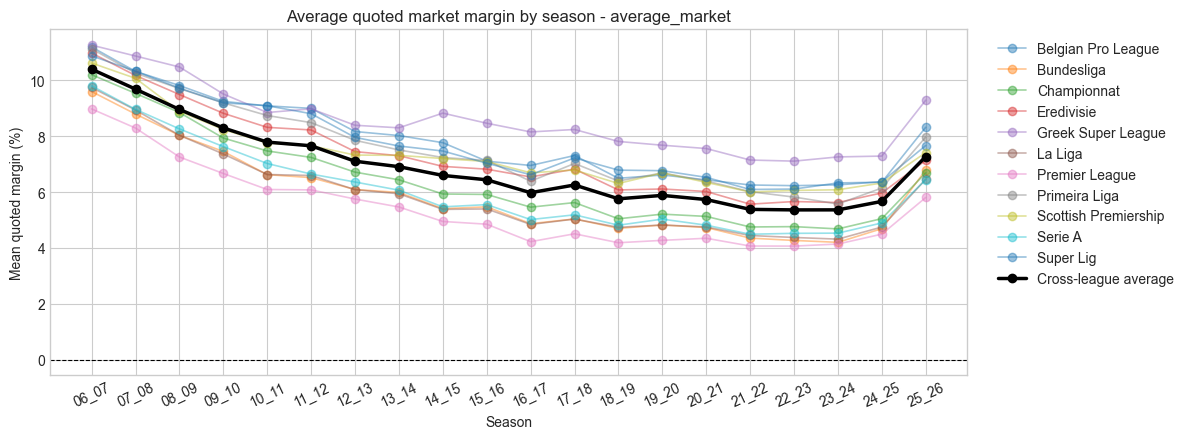

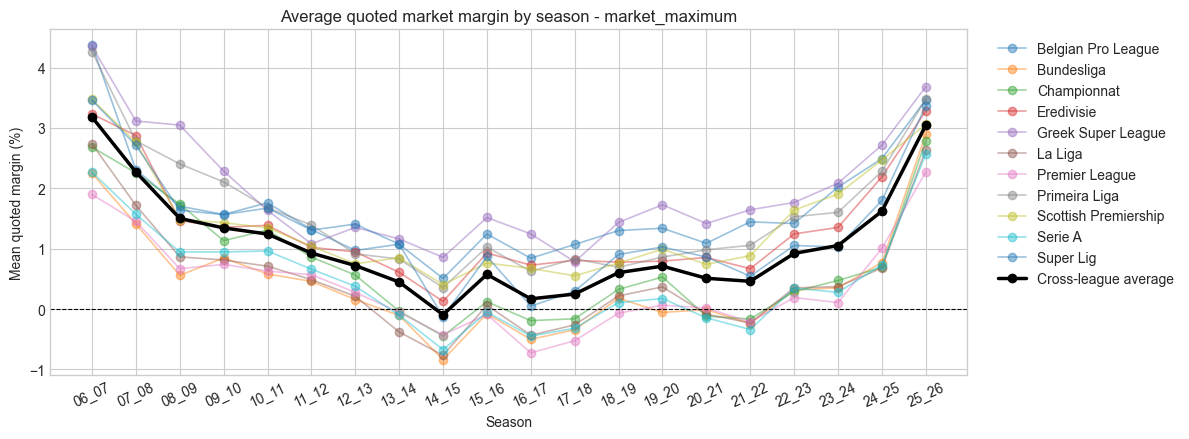

In [4]:
_ = plot_market_efficiency_margins(market_panel, primary_sources=PRIMARY_SOURCES, source_colors=SOURCE_COLORS)


## 3. Market-efficiency decision rule

The notebook follows the paper's decision-rule logic: estimate whether forecast errors are systematically related to the quoted implied probability, then bet only where the fitted efficiency curve is statistically positive.

For match \(i\), define the raw odds-implied probability and the realized binary outcome:

$$
p_i = \frac{1}{\text{odds}_i}
$$

$$
y_i =
\begin{cases}
1, & \text{if the selected outcome occurs}, \\
0, & \text{otherwise}.
\end{cases}
$$

The forecast error is:

$$
\varepsilon_i = y_i - p_i
$$

For each market source and league, the implemented model estimates one pricing-error curve from the available historical training seasons:

$$
\varepsilon_{i,s,j}
= \alpha_{s,j} + \beta_{s,j} p_{i,s,j} + \nu_{i,s,j}
$$

Here:

- s indexes the market source;
- j indexes the league;
- $\alpha_{s,j}$ is the estimated intercept for the source-league training sample;
- $\beta_{s,j}$ is the estimated slope versus implied probability for that source and league;
- $\nu_{i,s,j}$ is residual noise.

The fitted efficiency curve for a candidate probability \(p\) is:

$$
\widehat{G}_{s,j}(p)
= \widehat{\alpha}_{s,j} + \widehat{\beta}_{s,j} p
$$

The betting rule uses the lower 95% confidence bound:

$$
\widehat{G}_{s,j}(p)
- 1.96 \cdot \operatorname{SE}\!\left(\widehat{G}_{s,j}(p)\right)
> 0
$$

Algorithmically:

1. estimate the regression using previous seasons only;
2. compute the fitted efficiency curve and lower confidence bound;
3. identify the implied-probability range where the lower bound is positive;
4. bet out of sample on odds whose raw implied probability falls inside that accepted range.

This is an expanding-window walk-forward test when `TRAINING_WINDOW_SEASONS = None`: every test season uses all available earlier seasons, with no current-season or future-season outcomes included in parameter estimation.

The main specification keeps the key research choices fixed: the 11 top-division league universe, all available seasons, expanding-window calibration, and the 95% lower-confidence-bound decision rule. This reduces discretionary parameter search while keeping the test simple and transparent.


In [5]:
PAPER_RULE_NAME = "Paper lower 95% G(p) > 0"

In [6]:
paper_results = run_paper_rule_analysis(
    market_panel,
    training_window_seasons=TRAINING_WINDOW_SEASONS,
    min_train_seasons=MIN_TRAIN_SEASONS,
    min_train_matches=MIN_TRAIN_MATCHES,
    confidence_z=CONFIDENCE_Z,
    estimation_method=ESTIMATION_METHOD,
    paper_rule_name=PAPER_RULE_NAME,
)

paper_candidates = paper_results["paper_candidates"]
paper_bets = paper_results["paper_bets"]
paper_summary = paper_results["paper_summary"]
paper_season_summary = paper_results["paper_season_summary"]
paper_league_summary = paper_results["paper_league_summary"]
paper_season_league = paper_results["paper_season_league"]
paper_activity = paper_results["paper_activity"]

print(f"Estimation method: {ESTIMATION_METHOD}")
print(f"Training window: {'expanding, all previous seasons' if TRAINING_WINDOW_SEASONS is None else f'rolling last {TRAINING_WINDOW_SEASONS} previous seasons'}")
print(f"Paper-rule candidate rows: {len(paper_candidates):,}")
print(f"Paper-rule selected bets: {len(paper_bets):,}")
if not paper_activity.empty:
    active_cells = paper_activity.loc[paper_activity["selected_bets"].gt(0)]
    print(f"Active source-league-season cells: {len(active_cells):,} / {len(paper_activity):,}")

display(paper_summary)


Estimation method: ols_hc1
Training window: expanding, all previous seasons
Paper-rule candidate rows: 124,178
Paper-rule selected bets: 5,048
Active source-league-season cells: 51 / 396


,source,bets,total_stake,profit,roi_pct,hit_rate_pct,average_odds,average_ev_pct,market_outcome
0,average_market,1,1,0.07,7.00000,100.000000,1.070000,2.851860,home_win
1,market_maximum,5047,5047,115.92,2.29681,63.265306,1.820876,4.322833,home_win


## 4. Main flat-stake results

Flat-stake results use one unit per selected bet. ROI is:

$$
ROI = \frac{\sum profit}{\sum stake}.
$$

The key economic comparison is between the average quoted market price and the market-maximum price. A positive result for `market_maximum` is informative about the available best-price opportunity set. Because venue-level timestamps, liquidity, and account constraints are not available, it should not be interpreted as proof that every quoted price was executable at scale.


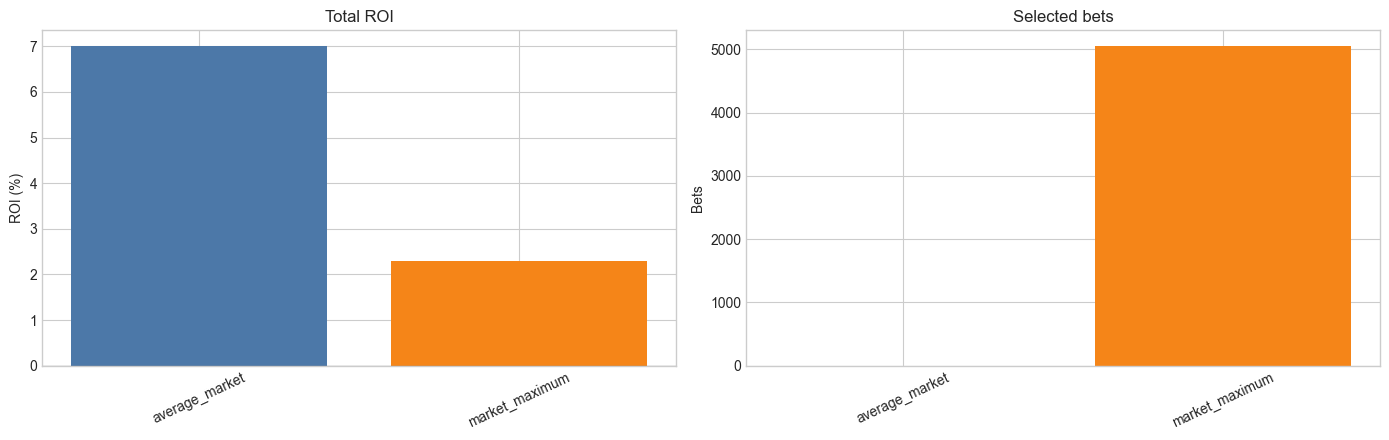

In [7]:
_ = plot_paper_rule_total_results(paper_summary, primary_sources=PRIMARY_SOURCES, source_colors=SOURCE_COLORS)


**Main empirical result from the saved run.** The economically meaningful result is `market_maximum`: the rule selects a substantial number of bets and produces positive flat-stake ROI. By contrast, `average_market` selects only one bet, so it is not an interpretable economic result. The evidence therefore supports a price-selection interpretation: in out-of-sample testing, value appears when the fitted decision rule is combined with better available prices relative to the quoted market average.


In [8]:
flat_result_table = (
    paper_summary.loc[
        paper_summary["source"].isin(PRIMARY_SOURCES),
        ["source", "bets", "roi_pct", "profit", "hit_rate_pct", "average_odds"],
    ]
    .sort_values("source", key=lambda values: values.map({source: i for i, source in enumerate(PRIMARY_SOURCES)}))
    .rename(
        columns={
            "source": "Source",
            "bets": "Bets",
            "roi_pct": "ROI (%)",
            "profit": "Profit",
            "hit_rate_pct": "Hit rate (%)",
            "average_odds": "Average odds",
        }
    )
)

display(flat_result_table.round({"ROI (%)": 2, "Profit": 2, "Hit rate (%)": 2, "Average odds": 3}))


,Source,Bets,ROI (%),Profit,Hit rate (%),Average odds
0,average_market,1,7.0,0.07,100.00,1.070
1,market_maximum,5047,2.3,115.92,63.27,1.821


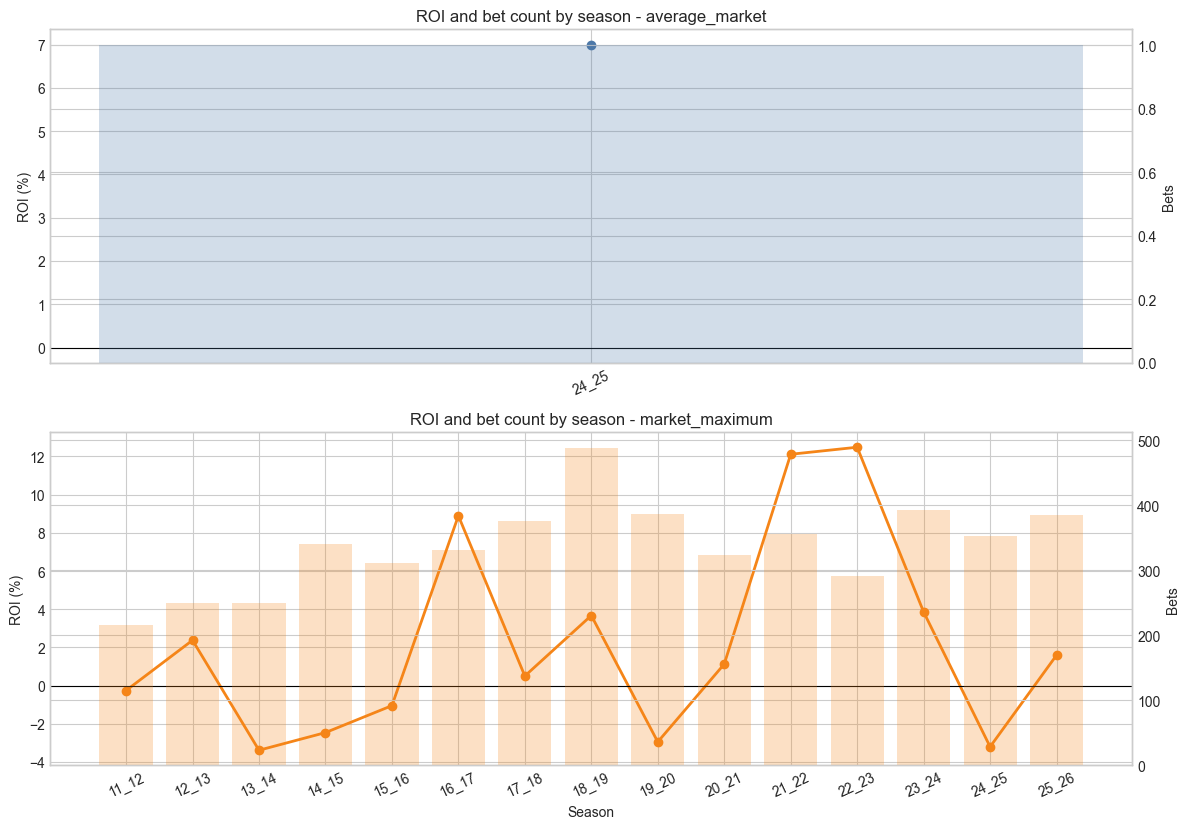

In [9]:
_ = plot_paper_rule_by_season(paper_season_summary, primary_sources=PRIMARY_SOURCES, source_colors=SOURCE_COLORS)


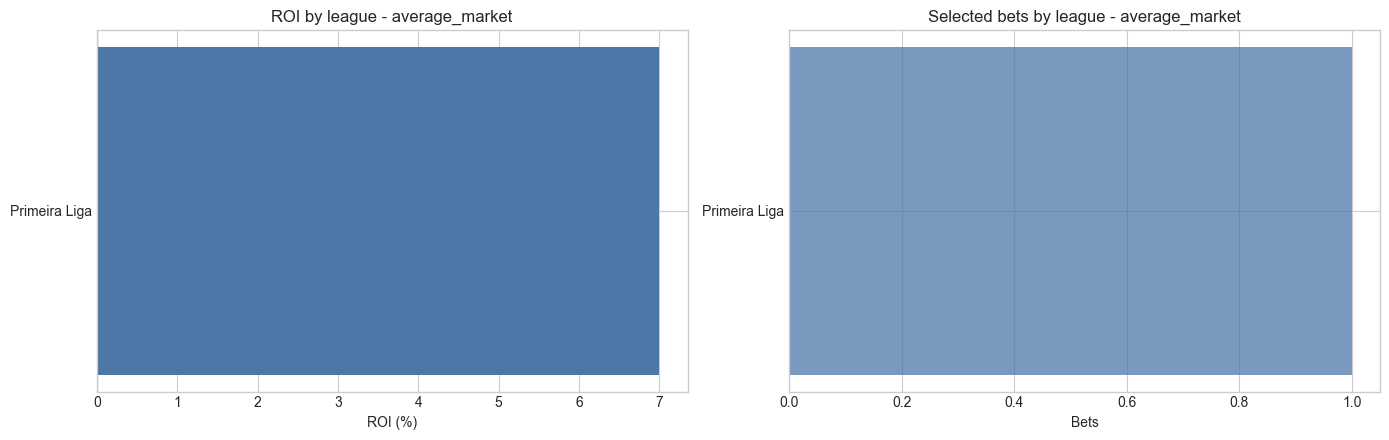

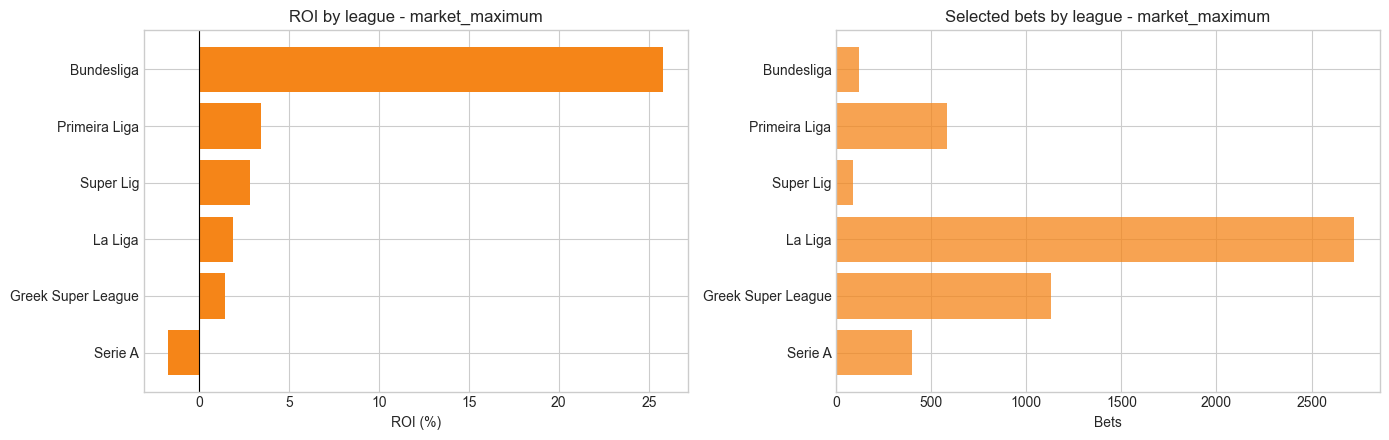

In [10]:
_ = plot_paper_rule_by_league(paper_league_summary, primary_sources=PRIMARY_SOURCES, source_colors=SOURCE_COLORS)


## 5. Robustness diagnostics

This section focuses only on `market_maximum`, where the paper-style rule selects enough bets to be economically interpretable. The goal is to check whether the positive flat-stake result is broad or mostly concentrated in a small number of season-league blocks.

The plots below show:

- block-bootstrap ROI distributions by season-league block and by season;
- profit concentration across winning season-league blocks;
- bet-level bootstrap intervals by season, compared with the observed season ROI.

The block bootstrap is deliberately more conservative than individual-bet resampling because it keeps part of the season/league clustering structure.


In [11]:
BOOTSTRAP_SIMS = 5_000
BOOTSTRAP_RANDOM_SEED = 42
BOOTSTRAP_SOURCE = "market_maximum"
PROFIT_CONTRIBUTION_LEVELS = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.75, 1.00]

robustness = build_robustness_diagnostics(
    paper_bets,
    source=BOOTSTRAP_SOURCE,
    simulations=BOOTSTRAP_SIMS,
    seed=BOOTSTRAP_RANDOM_SEED,
    contribution_levels=PROFIT_CONTRIBUTION_LEVELS,
)

market_maximum_bets = robustness["market_maximum_bets"]
season_league_blocks = robustness["season_league_blocks"]
season_blocks = robustness["season_blocks"]
season_league_bootstrap_roi = robustness["season_league_bootstrap_roi"]
season_bootstrap_roi = robustness["season_bootstrap_roi"]
bootstrap_roi = robustness["bootstrap_roi"]
season_league_bootstrap_summary = robustness["season_league_bootstrap_summary"]
season_bootstrap_summary = robustness["season_bootstrap_summary"]
robustness_summary = pd.concat(
    [season_league_bootstrap_summary, season_bootstrap_summary],
    ignore_index=True,
)
leave_one_out_summary = robustness["leave_one_out_summary"]
profit_contribution_summary = robustness["profit_contribution_summary"]
season_bet_level_bootstrap_summary = robustness["season_bet_level_bootstrap_summary"]

if market_maximum_bets.empty:
    print("No market-maximum paper-rule bets are available, so robustness diagnostics are skipped.")
else:
    print(
        f"Market-maximum robustness sample: {len(market_maximum_bets):,} bets, "
        f"{len(season_blocks):,} active seasons, "
        f"{len(season_league_blocks):,} active season-league blocks."
    )


Market-maximum robustness sample: 5,047 bets, 15 active seasons, 50 active season-league blocks.


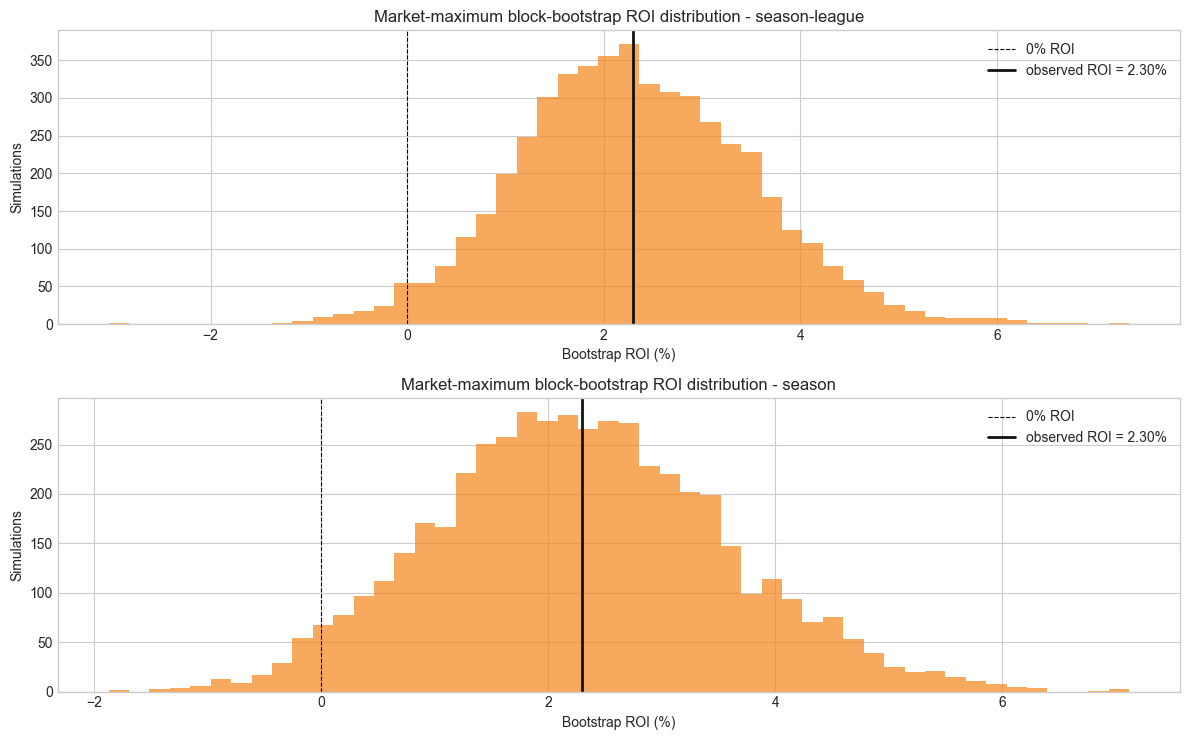

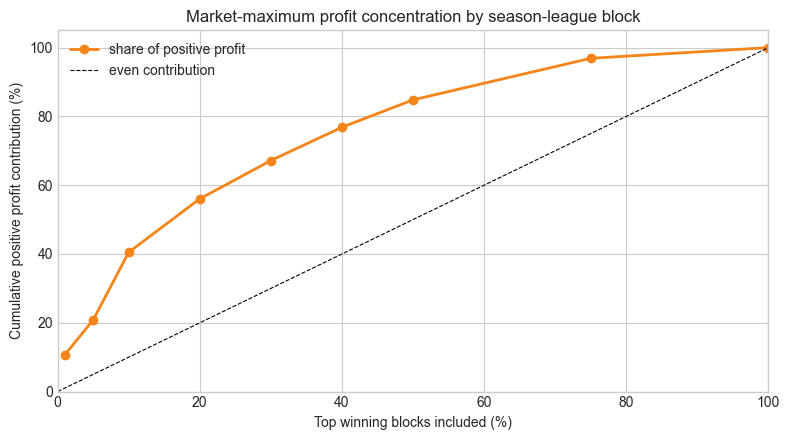

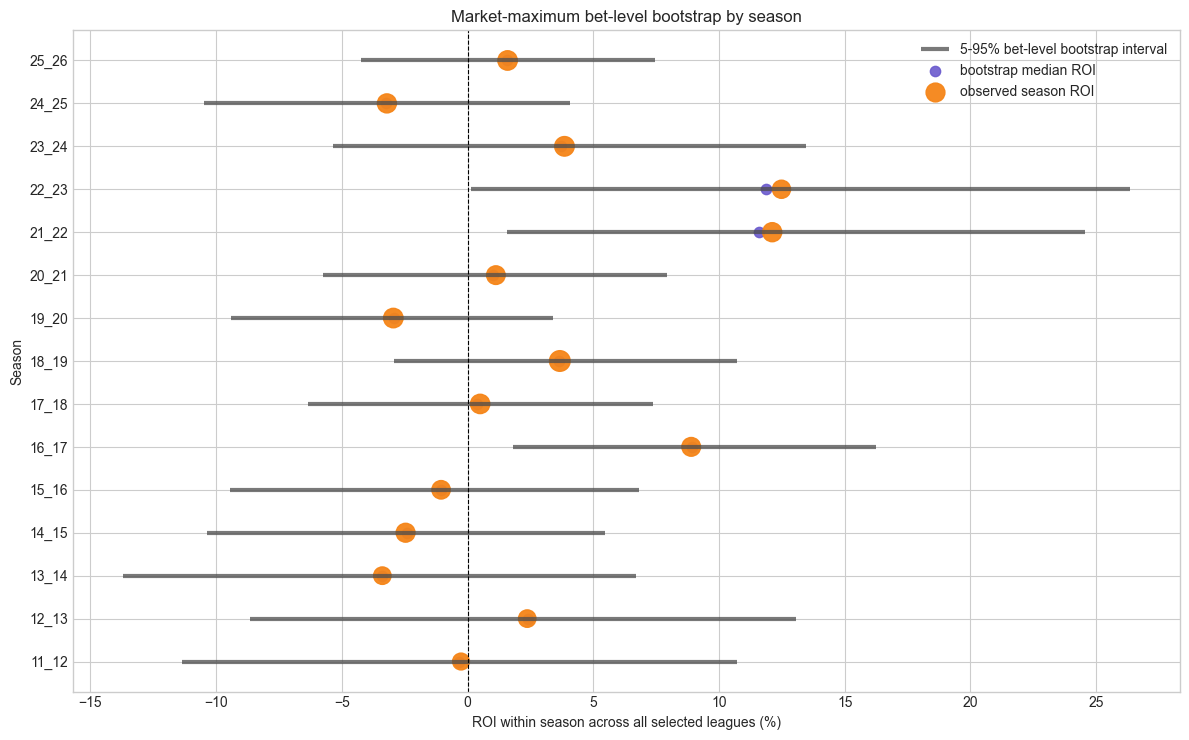

In [12]:
_ = plot_market_maximum_robustness(
    market_maximum_bets=market_maximum_bets,
    robustness_summary=robustness_summary,
    season_league_bootstrap_roi=season_league_bootstrap_roi,
    season_bootstrap_roi=season_bootstrap_roi,
    profit_contribution_summary=profit_contribution_summary,
    season_bet_level_bootstrap_summary=season_bet_level_bootstrap_summary,
    season_blocks=season_blocks,
    color=SOURCE_COLORS[BOOTSTRAP_SOURCE],
)


## 6. Fractional Kelly staking

Kelly staking is included as a path-risk and stake-sizing diagnostic on the same selected `market_maximum` bets. It does not change the decision rule or introduce a new signal.

The selected bets are exactly the same paper-rule `market_maximum` bets used above. Fractional Kelly is used because the estimated edge is noisy, and stake fractions are capped to avoid unrealistic leverage.

Let $p_i = 1/O_i$ be the raw implied probability, and let $\widehat{G}(p_i)$ be the fitted pricing-error adjustment estimated from prior seasons. Kelly staking uses the model-corrected probability:

$$
\widehat{q}_i = p_i + \widehat{G}(p_i)
$$

For decimal odds $O_i$, the full Kelly fraction is:

$$
f_i^* = \frac{\widehat{q}_i O_i - 1}{O_i - 1}.
$$

The bankroll plot shows compounded growth of the staking process. The season and league plots report return on staked capital, i.e. profit divided by the total amount actually staked in that group. These are related but not identical metrics, so they can rank Kelly fractions differently.

The saved run is constructive because the tested capped fractional-Kelly variants remain positive, supporting robustness to stake-sizing assumptions. This does not eliminate broader researcher degrees-of-freedom risk, but it makes the economic result less dependent on a single arbitrary staking fraction.


In [13]:
KELLY_SOURCE = "market_maximum"
INITIAL_BANKROLL = 1.0
KELLY_FRACTIONS = [0.10, 0.25]
MAX_KELLY_FRACTION = 0.05  # maximum stake per bet as a fraction of current bankroll
MAX_DATE_EXPOSURE_FRACTION = 0.25  # maximum total same-date exposure as a fraction of current bankroll
KELLY_BOOTSTRAP_SIMS = 2_000
KELLY_BOOTSTRAP_RANDOM_SEED = 123
KELLY_DRAWDOWN_THRESHOLD = 0.20

kelly = run_kelly_analysis(
    paper_bets,
    source=KELLY_SOURCE,
    initial_bankroll=INITIAL_BANKROLL,
    kelly_fractions=KELLY_FRACTIONS,
    max_bet_fraction=MAX_KELLY_FRACTION,
    max_date_exposure_fraction=MAX_DATE_EXPOSURE_FRACTION,
    bootstrap_sims=KELLY_BOOTSTRAP_SIMS,
    bootstrap_seed=KELLY_BOOTSTRAP_RANDOM_SEED,
    drawdown_threshold=KELLY_DRAWDOWN_THRESHOLD,
)

kelly_input = kelly["kelly_input"]
kelly_results = kelly["kelly_results"]
kelly_paths = kelly["kelly_paths"]
kelly_summary = kelly["kelly_summary"]
kelly_season_summary = kelly["kelly_season_summary"]
kelly_league_summary = kelly["kelly_league_summary"]
kelly_bootstrap_results = kelly["kelly_bootstrap_results"]
kelly_bootstrap_summary = kelly["kelly_bootstrap_summary"]

if kelly_results.empty:
    print("No market-maximum Kelly bets are available for the selected paper-rule configuration.")
else:
    print(
        f"Kelly source: {KELLY_SOURCE}; selected bets: {len(kelly_input):,}; "
        f"max per-bet stake: {MAX_KELLY_FRACTION:.1%}; "
        f"max same-date exposure: {MAX_DATE_EXPOSURE_FRACTION:.1%}."
    )
    display(kelly_summary.round(4))
    display(kelly_bootstrap_summary.round(4))


Kelly source: market_maximum; selected bets: 5,047; max per-bet stake: 5.0%; max same-date exposure: 25.0%.


,kelly_fraction,bets,final_bankroll,bankroll_return_pct,staking_roi_pct,total_stake,total_profit,average_stake_fraction_pct,max_stake_fraction_pct,max_drawdown_pct,hit_rate_pct,average_ev_pct
0,0.10,5047,5.0054,400.5447,3.7134,107.8649,4.0054,0.8929,5.0,11.8864,63.2653,4.3228
1,0.25,5047,18.5947,1759.4745,2.9542,595.5819,17.5947,1.9788,5.0,30.0510,63.2653,4.3228


,kelly_fraction,simulations,mean_return_pct,median_return_pct,p05_return_pct,p95_return_pct,probability_losing_money_pct,probability_drawdown_worse_than_threshold_pct
0,0.10,2000,437.5593,398.9348,153.0571,849.4790,0.00,40.45
1,0.25,2000,2706.3804,1743.9025,264.7897,8373.2844,0.15,100.00


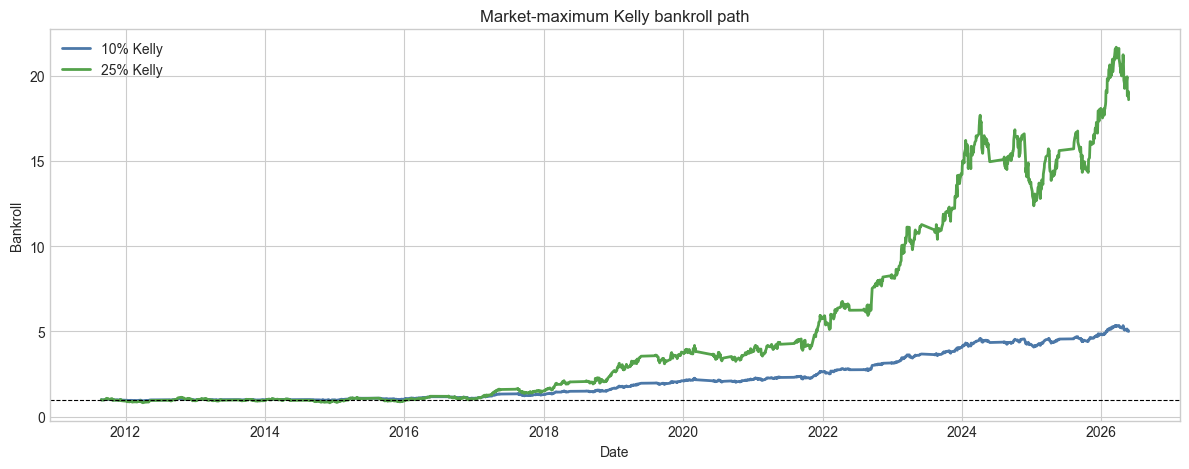

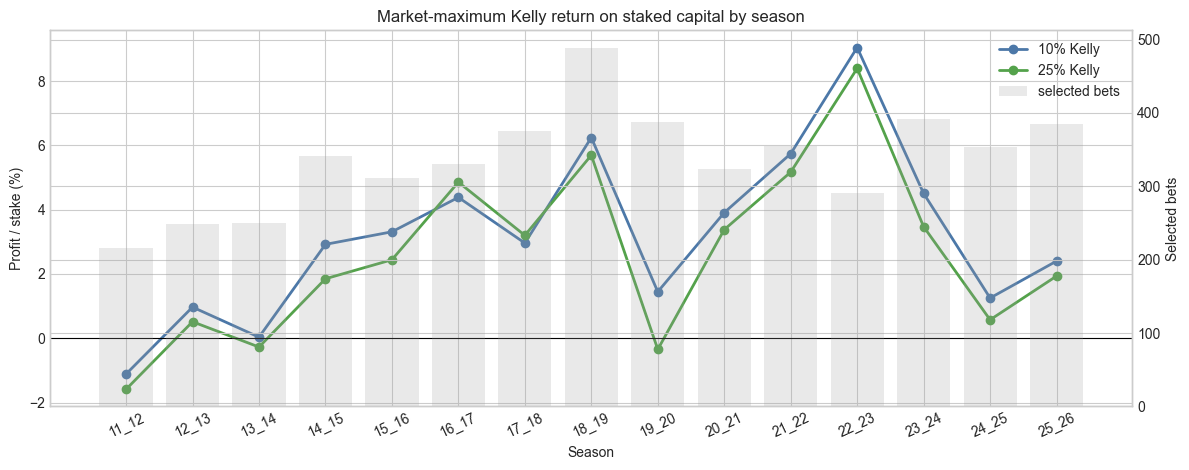

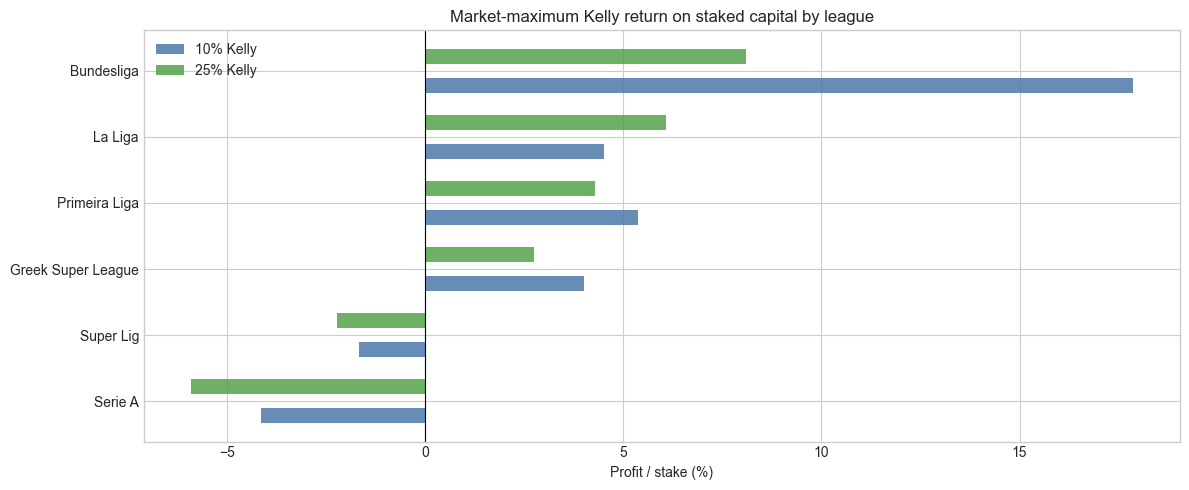

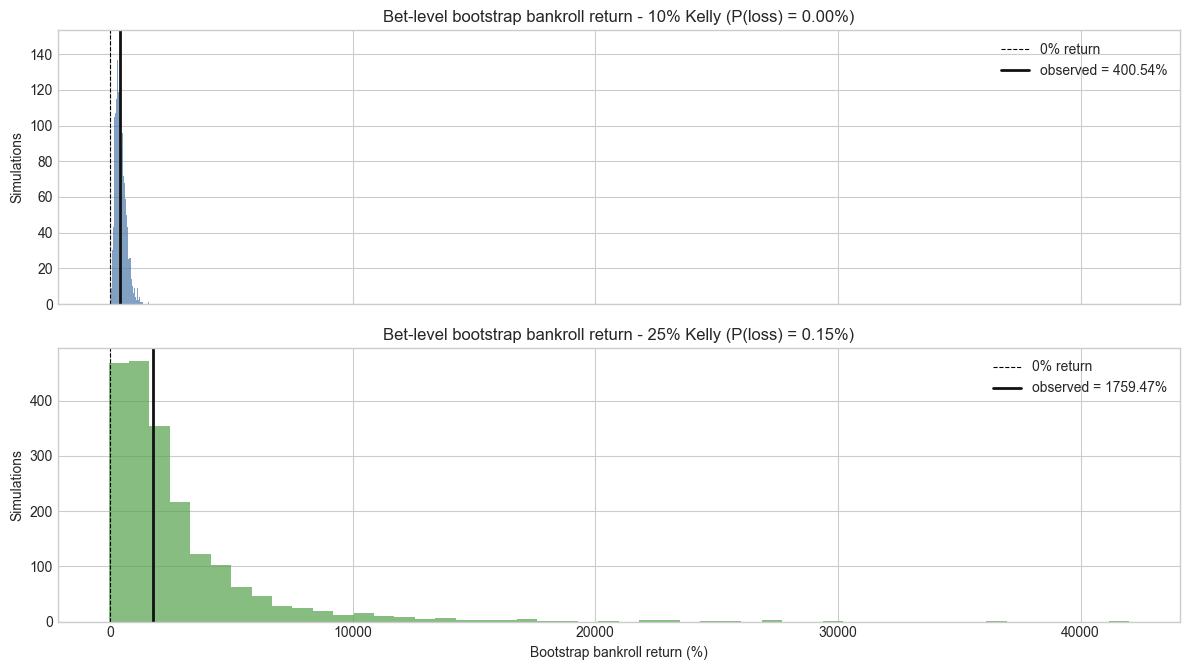

In [14]:
_ = plot_kelly_diagnostics(
    kelly_results=kelly_results,
    kelly_paths=kelly_paths,
    kelly_input=kelly_input,
    kelly_summary=kelly_summary,
    kelly_season_summary=kelly_season_summary,
    kelly_league_summary=kelly_league_summary,
    kelly_bootstrap_results=kelly_bootstrap_results,
    kelly_bootstrap_summary=kelly_bootstrap_summary,
    kelly_fractions=KELLY_FRACTIONS,
    initial_bankroll=INITIAL_BANKROLL,
)


## 7. Limitations

The results should be interpreted carefully, but the caveats do not make the `market_maximum` exercise uninformative.

- `market_maximum` is the best quoted price recorded within the Football-Data coverage universe and is directly relevant for studying price dispersion. The data contains odds snapshots but does not provide venue-level timestamps, so the exact timing and availability of each quoted price cannot be independently verified.
- Liquidity, account limits, commission, rejected bets, and execution frictions are not fully modeled.
- Venue coverage, market coverage, and sample sizes vary across seasons and leagues.
- COVID-era seasons may have different match and market dynamics, so results around `19_20` should be interpreted with some caution.
- Kelly results amplify model-estimated edge and are highly sensitive to probability-estimation error.
- The positive result is robust to the tested staking fractions, but broader multiple-testing and researcher-decision risk remains.
- Bootstrap diagnostics help assess robustness, but they do not prove live tradability.


## 8. Conclusions

This notebook provides positive evidence that a market-efficiency decision rule can identify economically meaningful price-selection opportunities in historical football betting data. The analysis uses all available seasons, 11 major European first divisions, and expanding-window walk-forward calibration, so each test season is evaluated using parameters estimated only from previous seasons.

The main empirical result is concentrated in `market_maximum`, where the rule selects a meaningful number of bets and generates positive flat-stake ROI in the saved run. The `average_market` result is not economically meaningful because only one bet is selected. This distinction is important: the evidence does not suggest that the average quoted market price is easy to exploit, but it does suggest that price dispersion can create measurable value when better available prices are selected.

Fractional Kelly results strengthen the economic interpretation. The same selected `market_maximum` bets remain positive under the tested capped fractional-Kelly specifications, indicating that the result is not dependent on a single staking fraction. Higher Kelly exposure still increases drawdown and path risk, so Kelly should be viewed as a sizing and robustness diagnostic rather than independent proof of an edge.

Overall, the notebook provides a coherent and credible market-efficiency study. The evidence is constructive: a paper-inspired decision rule, applied out of sample, identifies a positive historical `market_maximum` opportunity set. The result is best interpreted as evidence for a price-selection edge rather than a standalone forecasting-edge claim. Exact venue-level execution cannot be fully verified from the available data, but the results are strong enough to support the hypothesis that price dispersion can create economically meaningful opportunities in football betting markets.
